![Credit card fraud](https://www.bankdealguy.com/wp-content/uploads/2017/12/credit-card-banner.png)

# Credit card fraud detection

## Table of content
1) Environment setup  
 a) Importing packages  
 b) Loading dataset

2) Data manipulation  
 a) Null values  
 b) data category  
 c) Scaling values  
 d) Data splitting  
 e) Correlation matrix

3) Training model  
 a) Applying Stratified K fold and pipeline  
 b) Tuning Multiple models  
 c) Model Stacking  
 d) Threshold tuning   
 e) Final testing  

4) Undersampled dataset  
 a) creating dataset  
 b) model tuning  

## 1. Environmental setup

### a) Importing packages

In [20]:
# Core libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Remove warnings
import warnings
warnings.filterwarnings("ignore")

import joblib # Saving the trained model


### b) Loading dataset

In [21]:
df = pd.read_csv("creditcard.csv")

## 2. Data analysis

### a) Null values

In [22]:
print(f"Total null values: {df.isnull().sum().sum()}")

Total null values: 0


### b) Data category

This is an imbalanced dataset

In [23]:
print(f"Not Fraud: {df['Class'].value_counts()[0]}")
print(f"Fraud: {df['Class'].value_counts()[1]}")


Not Fraud: 284315
Fraud: 492


Finding duplicate records

In [24]:
duplicates = df.duplicated().sum()
print(f"Duplicates {duplicates}")

df = df.drop_duplicates()
print(f"After dropping duplicates: {df.shape[0]}")

Duplicates 1081
After dropping duplicates: 283726


### c) Data Splitting

In [25]:
X = df.drop('Class', axis=1)
y = df['Class']

# Train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=1
)

# Validation + Test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=1
)

### d) Scaling Values

This scaling is only done because I am using Logistic Regressor.  
The tree models doesnt require scaled values.  

In [26]:
X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
259021,158923.0,1.751110,-1.217634,-1.248006,-0.375733,-1.027579,-1.036205,-0.543211,-0.286739,-0.113454,...,0.502681,0.373010,0.765897,-0.083451,-0.013653,-0.190530,-0.115267,-0.002145,0.025886,219.00
132204,79896.0,-1.853782,0.924218,1.864239,-0.876365,-1.404122,-0.102966,-0.400768,0.992048,-0.041152,...,-0.320469,-0.014002,-0.196689,-0.075884,0.616682,0.141713,0.808112,-0.488831,-0.135641,46.91
21564,31739.0,1.212969,0.324455,0.283137,0.641189,-0.161641,-0.596653,0.027025,-0.080178,-0.010984,...,-0.095296,-0.256852,-0.694153,0.155535,0.041118,0.152094,0.123219,-0.004910,0.028008,1.98
75819,56269.0,0.087050,-1.547541,-0.839388,1.600529,-0.058722,0.331889,1.110655,-0.275008,-0.157169,...,1.142558,0.318999,-0.192974,-0.770419,-0.684518,0.699158,-0.247745,-0.081381,0.109981,608.85
13910,24680.0,1.294020,0.364968,-0.081084,0.481095,0.394243,0.046433,-0.121200,-0.060940,1.132666,...,-0.050600,-0.466401,-1.139435,-0.039215,-1.066696,0.336449,0.117806,-0.056115,0.002507,8.99


using RobustScaler, we will scale the time and amount columns.  
The scaling here is being done separately for amount and time because we treat RobustScaler() as a model and it works best when fit with a single kind of data.  
For X_train we use fit_transform because it learns the parameter and immediately applies them whereas  
X_test and X_val uses only transform because we dont want the model to learn these data and risk a data leakage.

In [27]:
amount_scaler = RobustScaler()
time_scaler = RobustScaler()

# Fit on train
X_train['Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_train['Time'] = time_scaler.fit_transform(X_train[['Time']])

# Transform val/test
X_val['Amount'] = amount_scaler.transform(X_val[['Amount']])
X_val['Time'] = time_scaler.transform(X_val[['Time']])

X_test['Amount'] = amount_scaler.transform(X_test[['Amount']])
X_test['Time'] = time_scaler.transform(X_test[['Time']])

### e) Correlation matrix

I will use undersampled data to find out correlation matrix

In this correlation matrix below, we can see that Features V14, V12, V10, V16 and V4, V11, V2, V19 are a strong correlation factor.

In [28]:
rus = RandomUnderSampler(random_state=1)

X_res, y_res = rus.fit_resample(X_train, y_train)

undersampled_df = X_res.copy()
undersampled_df['Class'] = y_res

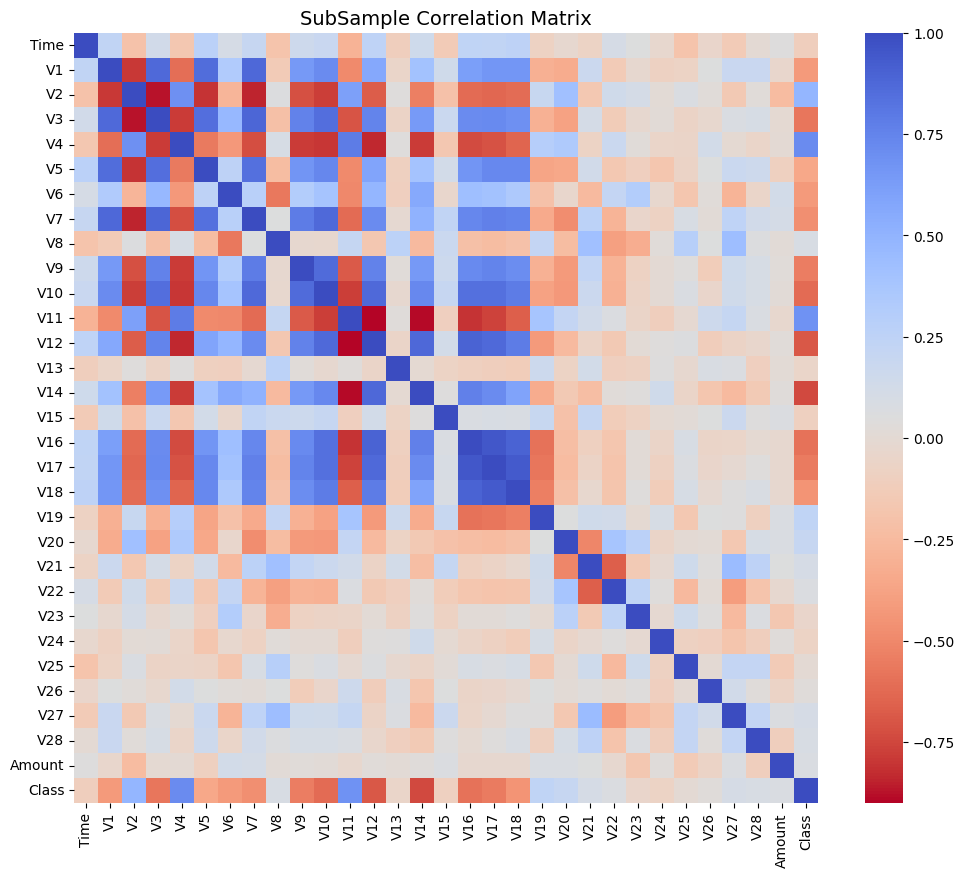

In [29]:
f, ax = plt.subplots(figsize=(12, 10))

# We are using the subsample database for this
corr = undersampled_df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title("SubSample Correlation Matrix", fontsize=14)
plt.show()

## 3. Training model

### a) Applying Stratified K fold and pipeline

StratifiedKFold is a cross-validation technique used to split data into k folds while preserving the class distribution in each fold.

In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

Pipelining the model and testing multiple parameters

In [31]:
models = {
    "log_reg": {
        "pipeline": Pipeline([
            ('model', LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced'))
        ]),
        "params": {
            "model__penalty": ['l1', 'l2'],
            "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
        }
    },

    "rf": {
        "pipeline": Pipeline([
            ('model', RandomForestClassifier(class_weight='balanced', random_state=1))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None]
        }
    },

    "xgb": {
        "pipeline": Pipeline([
            ('model', XGBClassifier(eval_metric='logloss', use_label_encoder=False))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.01, 0.1]
        }
    },

    "lgbm": {
        "pipeline": Pipeline([
            ('model', LGBMClassifier())
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__num_leaves": [31, 50],
            "model__learning_rate": [0.01, 0.1]
        }
    }
}

### b) Tuning Multiple models

Using GridCV to find out the best parameters.

In [32]:
# best_models = {}

# for name, config in models.items():
#     grid = GridSearchCV(
#         config["pipeline"],
#         config["params"],
#         scoring='f1',
#         cv=skf,
#         n_jobs=-1
#     )
    
#     grid.fit(X_train, y_train)
    
#     best_models[name] = grid.best_estimator_
    
#     print(f"{name} best params:", grid.best_params_)

# THIS ARE THE BEST PARAMETERS FOUND AFTER RUNNING GridCV
# log_reg best params: {'model__C': 0.001, 'model__penalty': 'l1'}
# rf best params: {'model__max_depth': None, 'model__n_estimators': 100}
# xgb best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
# lgbm best params: {'model__learning_rate': 0.01, 'model__n_estimators': 200, 'model__num_leaves': 50}


Implementing the best parameters so that training takes less time instead of running GridCV everytime

Logistic Regression

In [33]:
log_reg = LogisticRegression(
    penalty='l1',
    C=0.001,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced'
)

Random Forest Classifier

In [34]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=1
)

XG Boost Classifier

In [35]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0
)

LGBM Classifier

In [36]:
lgbm = LGBMClassifier(
    n_estimators=200,
    num_leaves=50,
    learning_rate=0.1,
    class_weight='balanced',
    verbosity=-1
)

### c) Model Stacking

Stacking 4 models and using Logistic Regressor as the final estimator.

In [37]:
stack_model = StackingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=skf,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C

Saving the model

In [38]:
joblib.dump(stack_model, "model.pkl", compress=3)

['model.pkl']

### d) Threshold tuning

In [39]:
# get probabilities on validation set
y_val_prob = stack_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.0, 1.0, 200)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_val_pred = (y_val_prob >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best threshold: {best_threshold}")
print(f"Best F1 Score: {best_f1}")

Best threshold: 0.2914572864321608
Best F1 Score: 0.8527131782945736


### e) Final testing

In [40]:
y_test_prob = stack_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("\nFinal Test Results:")
print(classification_report(y_test, y_test_pred))
print("Final Test F1:", f1_score(y_test, y_test_pred))


Final Test Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.92      0.79      0.85        71

    accuracy                           1.00     42559
   macro avg       0.96      0.89      0.92     42559
weighted avg       1.00      1.00      1.00     42559

Final Test F1: 0.8484848484848485


implementing confusion matrix

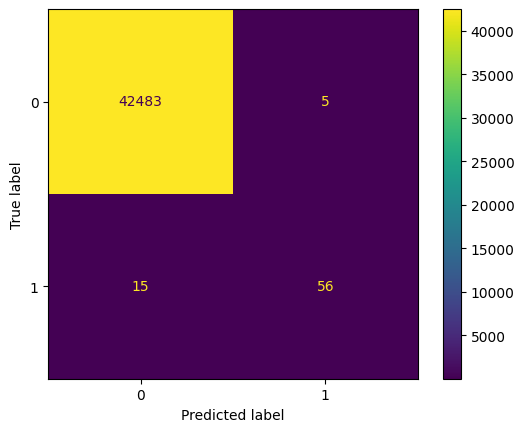

In [41]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

## 4. Undersampled dataset

### a) Creating dataset

I have already created the undersampled dataset in the correlation matrix section

In [42]:
print(undersampled_df['Class'].value_counts())
X_us = undersampled_df.drop('Class', axis=1)
y_us = undersampled_df['Class']

Class
0    331
1    331
Name: count, dtype: int64


The undersampled dataset is only taken from the training dataset, so we can directly use the whole dataset to train our model without train test split

### b) model tuning

In [43]:
# us_best_models = {}

# for name, config in models.items():
#     grid = GridSearchCV(
#         config["pipeline"],
#         config["params"],
#         scoring='f1',
#         cv=skf,
#         n_jobs=-1
#     )
    
#     grid.fit(X_us, y_us)
    
#     us_best_models[name] = grid.best_estimator_
    
#     print(f"{name} best params:", grid.best_params_)

# THIS ARE THE BEST PARAMETERS FOUND AFTER RUNNING GridCV
# log_reg best params: {'model__C': 1, 'model__penalty': 'l1'}
# rf best params: {'model__max_depth': 10, 'model__n_estimators': 200}
# xgb best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
# lgbm best params: {'model__learning_rate': 0.1, 'model__n_estimators': 200, 'model__num_leaves': 50}


Logistic regression

In [44]:
log_reg = LogisticRegression(
    penalty='l1',
    C=1,
    solver='liblinear',
    max_iter=1000
)

Random Forest Classifier

In [45]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=1
)

XG Boost Classifier

In [46]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    verbosity=0
)

LGBM Classifier

In [47]:
lgbm = LGBMClassifier(
    n_estimators=200,
    num_leaves=50,
    learning_rate=0.1,
    verbosity=-1
)

### c) Model stacking

In [48]:
us_stack_model = StackingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=skf,
    n_jobs=-1
)

us_stack_model.fit(X_us, y_us)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C

### d) Threshold tuning

In [49]:
# get probabilities on validation set
y_val_prob = us_stack_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.0, 1.0, 200)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_val_pred = (y_val_prob >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best threshold: {best_threshold}")
print(f"Best F1 Score: {best_f1}")

Best threshold: 0.9748743718592965
Best F1 Score: 0.7769784172661871


### e) Undersampled testing

In [50]:
y_test_prob = us_stack_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("\nFinal Test Results:")
print(classification_report(y_test, y_test_pred))
print("Final Test F1:", f1_score(y_test, y_test_pred))


Final Test Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.81      0.79      0.80        71

    accuracy                           1.00     42559
   macro avg       0.91      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559

Final Test F1: 0.8


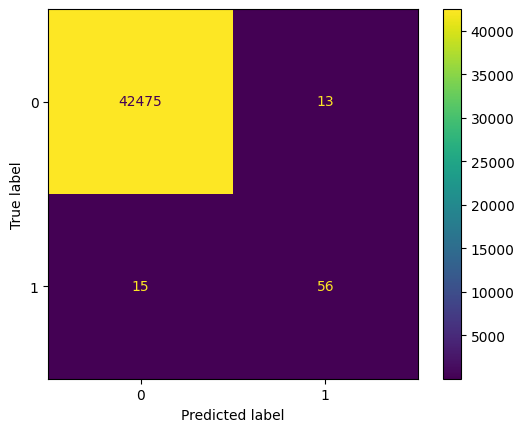

In [51]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

Conclusion: Undersampling produced worse result than implementing class weight on the original training dataset.  
Original dataset f1 score: 0.85  
Undersampled data f1 score: 0.80